# Predicting Stroke Risk using Machine Learning

**Author:** Radina Bakalov  

---

This notebook introduces foundational machine learning and data science concepts by exploring the problem of **stroke prediction**.

Given a patient's health and demographic information, we will build a model to predict whether or not they are at risk of having a stroke.

This project is designed as an end-to-end example of what a machine learning **proof of concept** looks like, including data exploration, preprocessing, modeling, and evaluation.

---

## What is classification?

Classification involves predicting whether a data point belongs to one class or another (**binary classification**).

In this case, we are predicting:
- **0 → No stroke**
- **1 → Stroke**

---

# Machine Learning Framework

## Problem Definition

In this project, we are solving a **binary classification problem**.

Given a patient's medical and lifestyle information, can we predict whether they are likely to have a stroke?

---

## What data are we using?

The dataset used in this project comes from Kaggle:  
**[Stroke Prediction Dataset (fedesoriano)](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)**

Each row represents a patient, and each column contains information about that patient.

### Key features include:

- `age`: Age of the patient  
- `gender`: Male, Female, or Other  
- `hypertension`: Whether the patient has hypertension  
- `heart_disease`: Whether the patient has heart disease  
- `ever_married`: Marital status  
- `work_type`: Type of employment  
- `Residence_type`: Urban or Rural  
- `avg_glucose_level`: Average glucose level in blood  
- `bmi`: Body Mass Index  
- `smoking_status`: Smoking history  
- `stroke`: Target variable (1 = stroke, 0 = no stroke)

This dataset reflects real-world conditions and includes **missing values** and **categorical variables**, which we will need to handle during preprocessing.

---

## How will we evaluate our model?

Choosing the right evaluation metric is critical, especially for imbalanced datasets like this one.

Because stroke cases are rare, accuracy alone can be misleading.

We will focus on:
- **Recall** → How many actual stroke cases we correctly identify  
- **Precision** → How many predicted stroke cases are actually correct  
- **F1-score** → Balance between precision and recall  
- **ROC-AUC** → Overall model performance across thresholds  

Our goal is not just high accuracy, but a model that can effectively **identify stroke risk**.

---

## Which features of the data will be important?

Features represent the characteristics of each patient that the model uses to make predictions.

To better understand the dataset, we will explore:
- The distribution of each feature  
- Relationships between features and stroke occurrence  
- Potential correlations  

We will also create a **data dictionary** to clearly define each feature and its role in the dataset.

---

## Stroke Dataset Overview

| Feature | Description |
|--------|------------|
| id | Unique identifier |
| gender | Patient's gender |
| age | Age in years |
| hypertension | 1 = Yes, 0 = No |
| heart_disease | 1 = Yes, 0 = No |
| ever_married | Marital status |
| work_type | Employment type |
| Residence_type | Urban or Rural |
| avg_glucose_level | Average blood glucose level |
| bmi | Body Mass Index (may contain missing values) |
| smoking_status | Smoking history |
| stroke | Target variable (1 = stroke, 0 = no stroke) |

---

### Note
- The dataset is **imbalanced**, meaning stroke cases are much less frequent than non-stroke cases.
- Special care will be taken during modeling to handle this imbalance properly.

---

This notebook will walk through the full machine learning pipeline, from raw data to model evaluation.

# 1. Preparing the tools

Before diving into the data, we first need to set up the tools that will be used throughout this project.

In many tutorials, you'll see all required libraries imported at once at the beginning. In reality, it's common to import libraries gradually as you figure out what you need while working through the problem.

Once the workflow becomes clearer, it's helpful to organize and group all imports at the top of the notebook for readability.

For this project, we’ll rely on a core set of libraries that are commonly used in machine learning with structured data:

- **pandas** for working with and analyzing data  
- **NumPy** for handling numerical computations  
- **Matplotlib / seaborn** for creating visualizations  
- **Scikit-learn** for building and evaluating machine learning models  

These libraries will support everything from initial data exploration to model training and evaluation.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns 

# Models
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer # for filling in missing BMI values

# Optional but might be fun to try
# from xgboost import XGBClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, RocCurveDisplay, roc_auc_score

# 2. Load our data

In [4]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print(f"{df.shape[0]} rows x {df.shape[1]} columns")

5110 rows x 12 columns


In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


# 3. Data Exploration

Before building any models, it's important to understand the dataset we're working with.

In this step, we explore the structure, features, and overall quality of the data. This helps identify potential issues such as missing values, incorrect data types, or imbalanced classes.

---

## 3.1 Understanding the data structure

We start by taking a look at the dataset using methods like `.info()` and `.head()`.

This gives us:
- The number of rows and columns  
- The data types of each feature  
- A quick preview of what the data looks like  

From this, we can see that the dataset contains both **numerical** and **categorical** features, which will require different preprocessing steps later on.

---

## 3.2 Summary statistics

Next, we use `.describe()` to get a statistical summary of the numerical features.

This includes:
- Mean and standard deviation  
- Minimum and maximum values  
- Quartiles (25%, 50%, 75%)  

These statistics help us better understand the distribution of features like age, glucose level, and BMI, and can also highlight potential outliers.

---

## 3.3 Missing values

Handling missing data is an important part of any machine learning workflow.

From our inspection, we can see that:
- The **bmi** feature contains missing values  
- Most other features are complete  

We will need to decide how to handle these missing values later, either by:
- Filling them in (imputation), or  
- Removing affected rows  

---

## 3.4 Initial observations

Based on this initial exploration, a few key points stand out:

- The dataset contains a mix of numerical and categorical variables  
- The **bmi** column has missing values that need to be addressed  
- The target variable (`stroke`) appears to be imbalanced (to be explored further)  

These observations will guide how we preprocess the data before training our models.

---

This initial exploration provides a solid understanding of the dataset and prepares us for the next step: cleaning and preprocessing the data.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [8]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [9]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
# Let's find out how many of each class there are
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

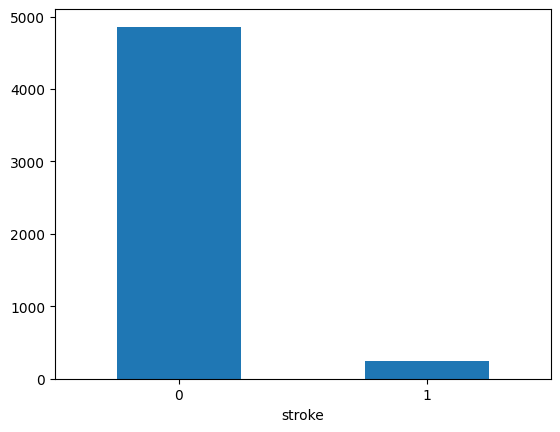

In [11]:
df["stroke"].value_counts().plot(kind="bar");
plt.xticks(rotation=0);

In [12]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [13]:
# "Other" is just 1 row in the whole dataset 
# We are going to need to drop it before splitting, 
# otherwise it might end up only in the test set and break our encoder
df = df[df["gender"] != "Other"]

In [14]:
# Compare the target column with the gender column
pd.crosstab(df["stroke"], df["gender"])

gender,Female,Male
stroke,,
0,2853,2007
1,141,108


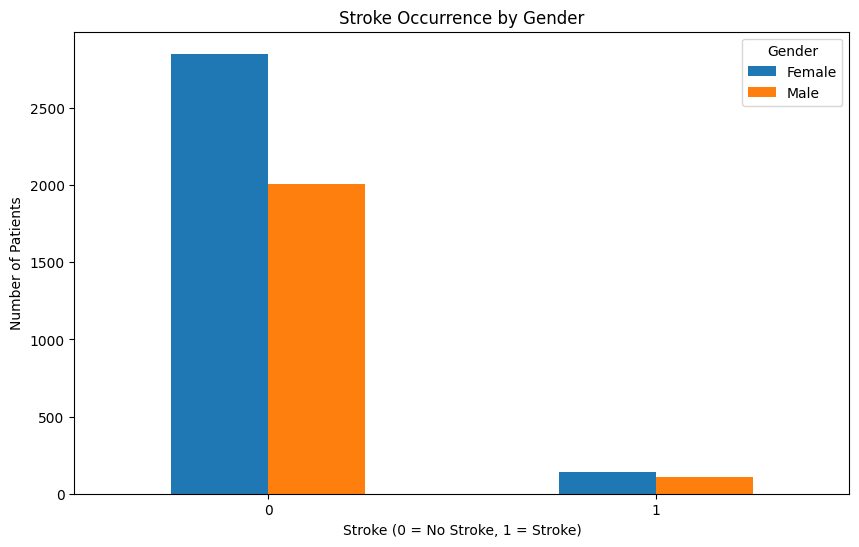

In [15]:
# Create a plot fo that crosstab
pd.crosstab(df["stroke"], df["gender"]).plot(kind="bar",
                                             figsize=(10, 6))

plt.title("Stroke Occurrence by Gender")
plt.xlabel("Stroke (0 = No Stroke, 1 = Stroke)")
plt.ylabel("Number of Patients")
plt.legend(title="Gender")
plt.xticks(rotation=0);

In [16]:
df["age"][df["stroke"]==1]

0      67.0
1      61.0
2      80.0
3      49.0
4      79.0
       ... 
244    57.0
245    14.0
246    75.0
247    71.0
248    78.0
Name: age, Length: 249, dtype: float64

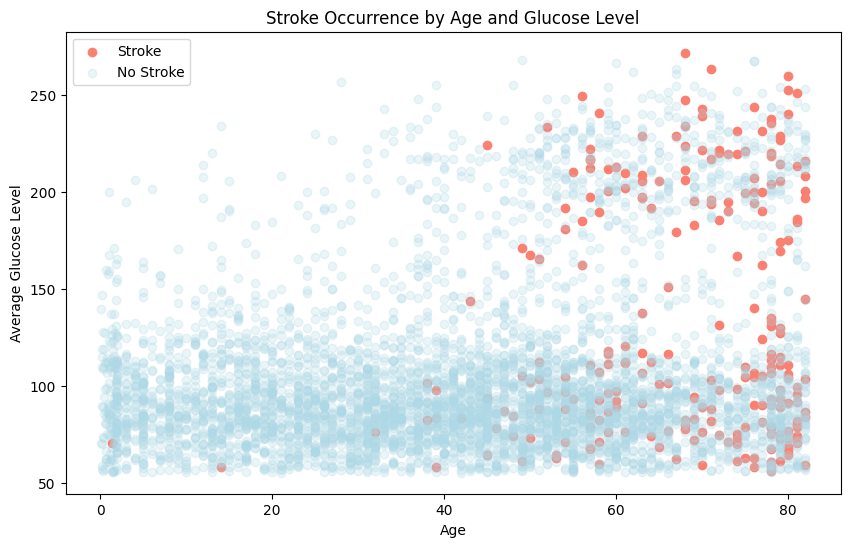

In [17]:
# Let's create another figure 
plt.figure(figsize=(10, 6))

# Scatter with positive examples
plt.scatter(df["age"][df["stroke"] == 1],
            df["avg_glucose_level"][df["stroke"] == 1],
            c="salmon",
            label="Stroke")

# Scatter with negative examples
plt.scatter(df["age"][df["stroke"] == 0],
            df["avg_glucose_level"][df["stroke"] == 0],
            c="lightblue",
            alpha=0.25,
            label="No Stroke")

# Add some helpful info
plt.title("Stroke Occurrence by Age and Glucose Level")
plt.xlabel("Age")
plt.ylabel("Average Glucose Level")
plt.legend();

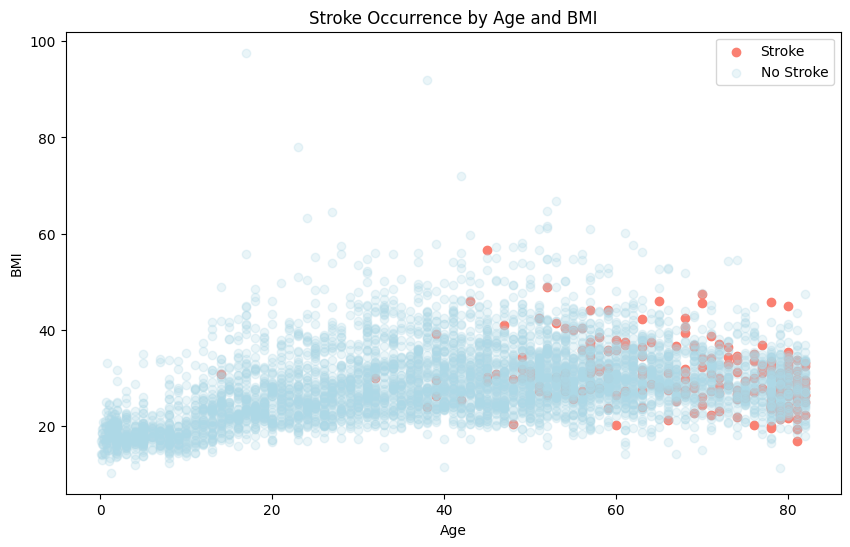

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(df["age"][df["stroke"] == 1],
            df["bmi"][df["stroke"] == 1],
            c="salmon",
            label="Stroke")

plt.scatter(df["age"][df["stroke"] == 0],
            df["bmi"][df["stroke"] == 0],
            c="lightblue",
            alpha=0.25,
            label="No Stroke")

plt.title("Stroke Occurrence by Age and BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend();

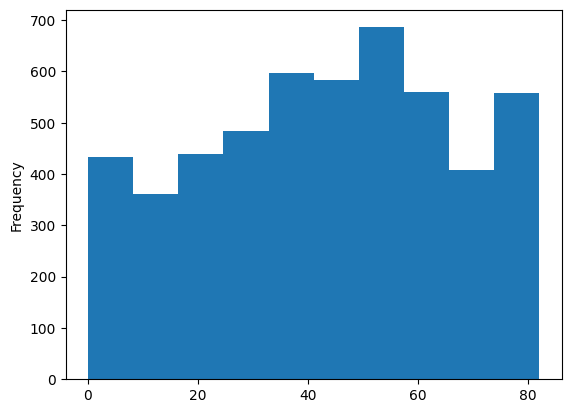

In [19]:
# Check the distribution of the age column with a histogram 
df["age"].plot.hist();

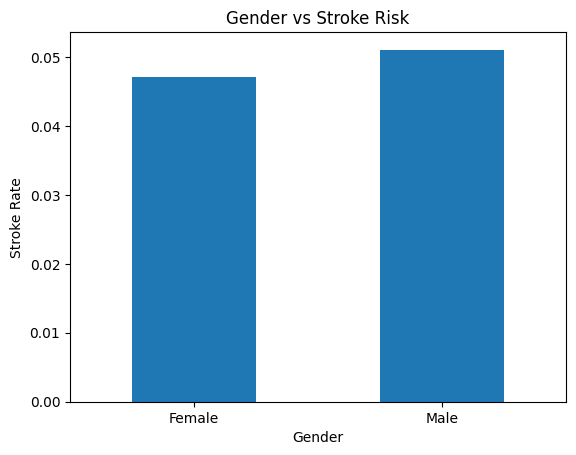

In [20]:
# Calculate the average stroke rate per gender (this gives us the proportion of stroke cases, not raw counts)
stroke_by_gender = df.groupby("gender")["stroke"].mean() # group the dataset by gender, then select the stroke column within each group

# Now let's plot the summary, not the raw data
stroke_by_gender.plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Stroke Rate")
plt.title("Gender vs Stroke Risk")
plt.xticks(rotation=0) # keep the labels flat
plt.show();

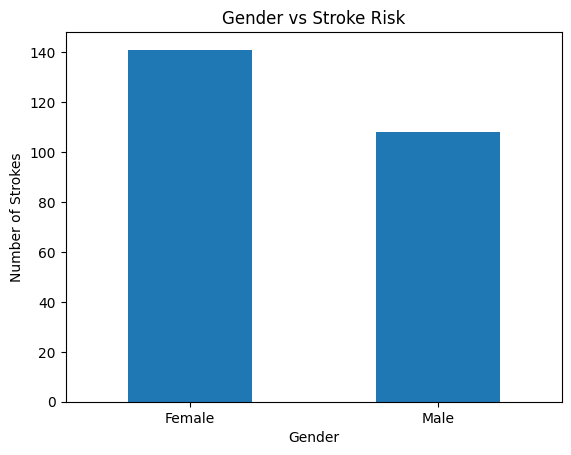

In [21]:
# Calculate the number of strokes per gender
stroke_by_gender = df.groupby("gender")["stroke"].sum() # group the dataset by gender, then select the stroke column within each group

# Now let's plot the summary
stroke_by_gender.plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Number of Strokes")
plt.title("Gender vs Stroke Risk")
plt.xticks(rotation=0) # keep the labels flat
plt.show();

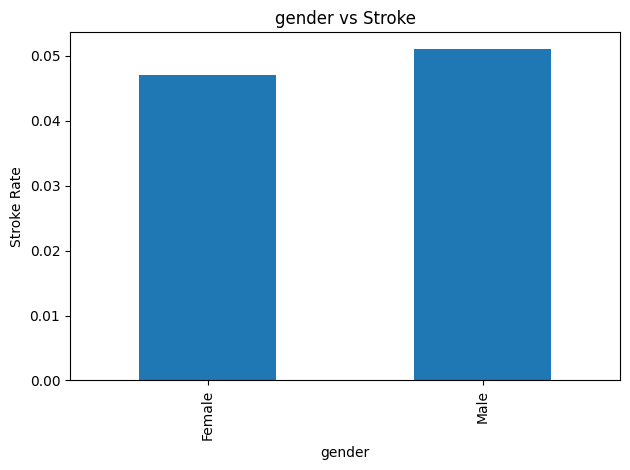

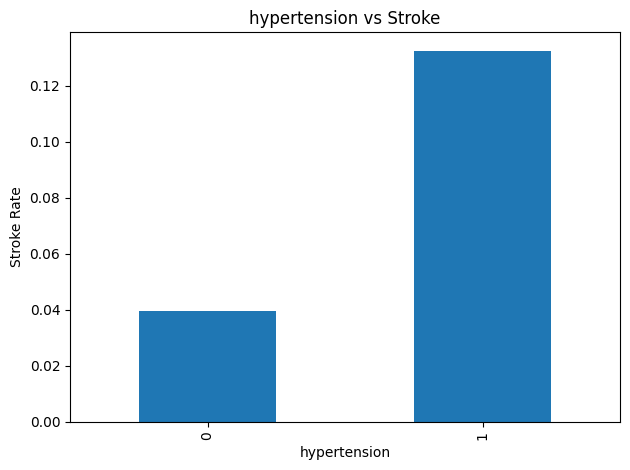

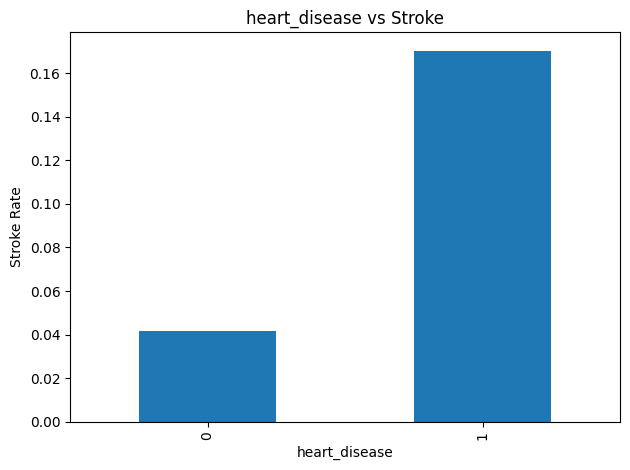

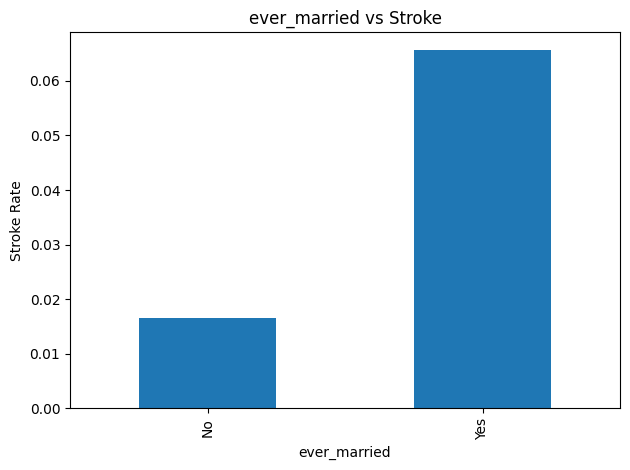

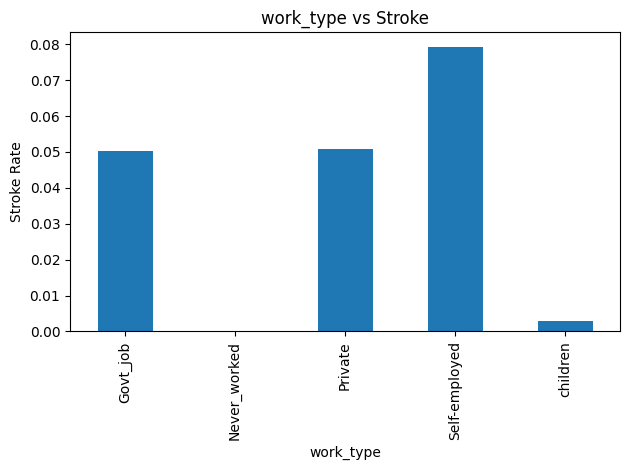

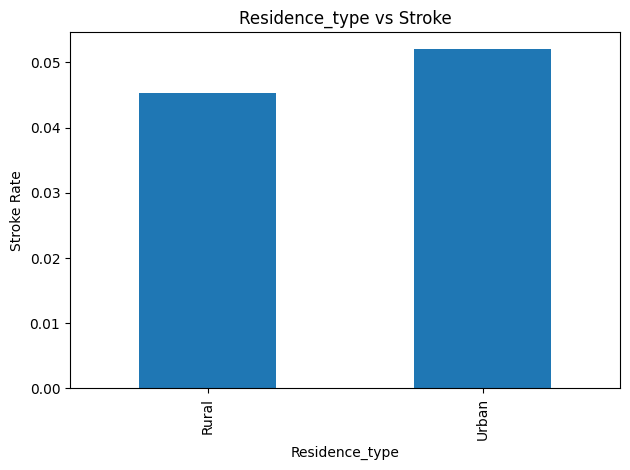

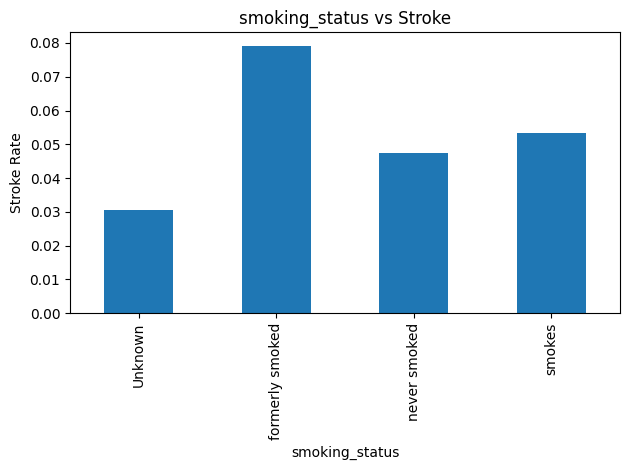

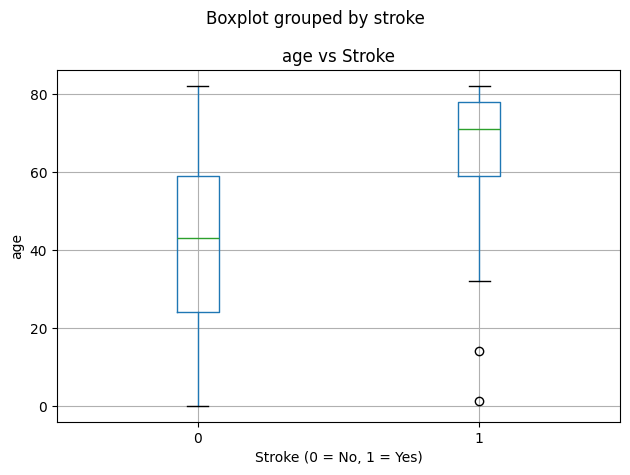

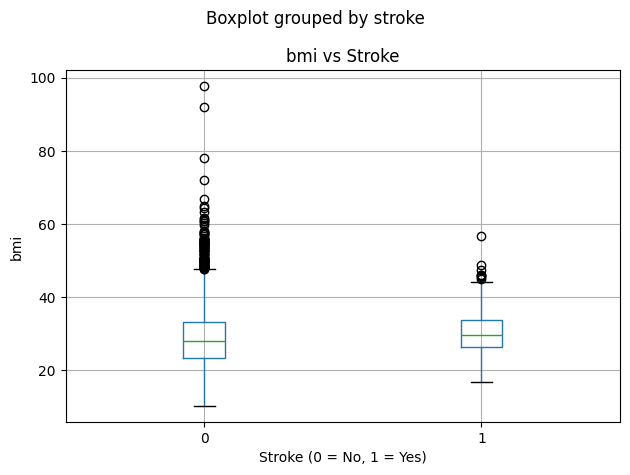

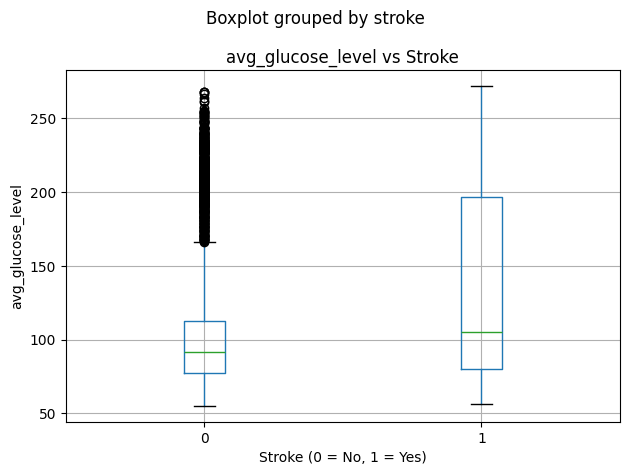

In [22]:
# Columns that are categorical (text labels)
CATEGORICAL = ["gender", "hypertension", "heart_disease", "ever_married", 
               "work_type", "Residence_type", "smoking_status"]

# Columns that are actual numbers 
NUMERICAL = ["age", "bmi", "avg_glucose_level"]

def plot_feature_vs_stroke(df, feature):
    fig, ax = plt.subplots()

    if feature in CATEGORICAL:
        # Group by category and get the stroke rate for each group
        stroke_rate = df.groupby(feature)["stroke"].mean()
        stroke_rate.plot(kind="bar", ax=ax)
        ax.set_xlabel(feature)
        ax.set_ylabel("Stroke Rate")

    elif feature in NUMERICAL:
        # Boxplot lets us see if the stroke patients have higher or lower values
        df.boxplot(column=feature, by="stroke", ax=ax)
        ax.set_xlabel("Stroke (0 = No, 1 = Yes)")
        ax.set_ylabel(feature)

    ax.set_title(f"{feature} vs Stroke")
    plt.tight_layout()
    plt.show()
        
# Loop through everything
for col in CATEGORICAL + NUMERICAL:
    plot_feature_vs_stroke(df, col)

# 4. Modeling

We've explored the data, now it's time to actually build something.

Remember our problem?

> Given a patient's health and demographic information, can we predict whether or not they are at risk of having a stroke?

That's what we've been working toward.

And remember our evaluation metric?

> Because stroke cases are rare in this dataset, we can't rely on accuracy alone. 
> We'll focus on **recall** — making sure we catch as many actual stroke cases as possible.

That's what we'll be optimizing for.

But before we throw any data at a model, we need to get it ready first.

Let's take one more look at it.

In [23]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


We're trying to predict `stroke` using all the other columns as inputs.

To do that, we split things into two pieces:

- `X` — our features (everything except the `stroke` column)
- `y` — our target (just the `stroke` column)

We also need to handle a couple of things before modeling:
- **Missing values** in `bmi`
- **Categorical columns** that need to be converted to numbers
- **Class imbalance** — stroke cases make up only about 5% of the data

In [24]:
# Split our data into X and y
# X will be everything except our stroke variable
X = df.drop("stroke", axis=1)

# Y will be our target variable, aka the stroke variable
y = df["stroke"]

In [25]:
X.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked


In [26]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: stroke, dtype: int64

In [27]:
np.random.seed(42)

# Split into train & test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [28]:
X_train.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
802,4970,Male,79.0,0,0,Yes,Self-employed,Rural,112.64,28.5,formerly smoked
3927,56137,Female,62.0,0,0,Yes,Private,Urban,88.32,36.3,Unknown
2337,54590,Female,21.0,0,0,No,Private,Rural,59.52,33.7,never smoked
3910,36548,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked
1886,61171,Female,31.0,0,0,No,Private,Rural,59.63,19.9,never smoked


In [29]:
y_train, len(y_train)

(802     0
 3927    0
 2337    0
 3910    0
 1886    0
        ..
 4427    0
 466     0
 3092    0
 3773    0
 860     0
 Name: stroke, Length: 4087, dtype: int64,
 4087)

## 4.1 Choosing a Model

Now that our data is ready, we can start trying out some models.

There are a lot of machine learning algorithms out there, and picking the "right" one 
upfront is nearly impossible. The better approach is to try a few and see what works.

We'll start with these five:

1. Logistic Regression - `sklearn.linear_model.LogisticRegression()`
2. K-Nearest Neighbors - `sklearn.neighbors.KNeighborsClassifier()`
3. Decision Tree - `sklearn.tree.DecisionTreeClassifier()`
4. Random Forest - `sklearn.ensemble.RandomForestClassifier()`
5. Gradient Boosting - `sklearn.ensemble.GradientBoostingClassifier()`

### Why these?

These are all solid, well-established classification algorithms that work well on 
tabular data like ours. Think of them as five different doctors all looking at the 
same patient. We want to see who gives the best diagnosis.

For now, we don't need to know every detail of how each one works under the hood. 
What matters is understanding that:

- We have a **classification problem** (stroke or no stroke)
- These algorithms all know how to handle that
- They all share the same sklearn interface, so we can train and compare them in a loop

Since our dataset is relatively small, running all five is quick and gives us a much 
better picture than committing to just one.

One important note: because of our **class imbalance**, we won't just look at accuracy. 
A model that predicts "no stroke" for everyone would be ~95% accurate and completely 
useless. We care about **recall**: catching actual stroke cases.

In [30]:
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Decision Tree": DecisionTreeClassifier(),
          "Random Forest": RandomForestClassifier(),
          "Gradient Boosting": GradientBoostingClassifier(),}

# Make a function the fits and scores our models 
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates our machine learning models.
    models: a dictionary containing different Scikit-Learn machine learning models
    X_train: our training data
    X_test: our testing data
    y_train: the labels assosciated with the training data
    y_test: the labels assosciated with the test data
    """
    # Random seed
    np.random.seed(42)

    # Make a list to keep the scoring of the models
    model_scores = {}

    # Loop through each model 
    for name, model in models.items():
        # Fit the model to the TRAINING data 
        model.fit(X_train, y_train)
        # Evaluate the model on the TEST data and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [31]:
# WAIT, think about this now.
# This will error! Hmmmm, let's think about why...

# model_scores = fit_and_score(models=models,
#                              X_train=X_train,
#                              X_test=X_test,
#                              y_train=y_train,
#                              y_test=y_test)

# model_scores

## 4.2 Preprocessing: Getting the Data Model-Ready

Before we can actually run our models, we need to do a bit of cleanup!

If you try to run `fit_and_score` right now, it'll throw an error (just like we just saw) 
and that's expected! Our data still has a few things sklearn can't handle:

- **Text columns** like `"Male"`, `"Private"`, `"never smoked"` — models only speak numbers
- **Missing values** in `bmi` — most models can't deal with blanks
- **The `id` column** — it's just a row number, completely meaningless for prediction

So we need to fix all three before we can train anything.

Here's what we'll do:

1. **Drop `id`** — it carries no useful signal
2. **Impute missing `bmi` values** — we'll fill in the blanks with the median BMI
3. **Encode categorical columns** — convert text categories into numbers using `LabelEncoder`

### One important rule: fit on train, transform on test

We always fit our imputer and encoder **only on the training data**, then apply 
them to the test data. 

Why? Because the test set is supposed to represent data we've never seen before. 
If we peek at it during preprocessing, we're accidentally leaking information into 
our model and our results won't reflect how it would actually perform in the real world.

All right, let's go!

In [32]:
# Let's drop id as it's just a row numbers and it's not useful for predicting anything
X_train = X_train.drop("id", axis=1)
X_test = X_test.drop("id", axis=1)

# Fill in missing bmi values with the average bmi (median is safer with outliers!)
bmi_imputer = SimpleImputer(strategy="median")
# fit_transform on train -> two things happening at once:
# step 1 (fit): "look at all the BMI values in training data, calculate the median"
# step 2 (transform): "now fill in any missing BMI values using that median"
X_train["bmi"] = bmi_imputer.fit_transform(X_train[["bmi"]]) # --> SimpleImputer needs double brackets (expects a table)
# transform only on test -> one thing:
# "use the median you already calculated from training data to fill in test blanks"
# we do NOT let it recalculate the median from test data
X_test["bmi"] = bmi_imputer.transform(X_test[["bmi"]]) # use same imputer, don't refit!

# Now let's convert all of our text columns to numbers
# LabelEncoder turns e.g. "Male"/"Female" into 0/1
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

le = LabelEncoder()
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col]) # --> LabelEncoder needs single brackets (expects a plain list)
    X_test[col] = le.transform(X_test[col]) # same rule here, fit on the train data, then apply to the test data

In [33]:
X_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
802,1,79.0,0,0,1,3,0,112.64,28.5,1
3927,0,62.0,0,0,1,2,1,88.32,36.3,0
2337,0,21.0,0,0,0,2,0,59.52,33.7,2
3910,1,31.0,0,0,1,0,1,65.70,30.4,1
1886,0,31.0,0,0,0,2,0,59.63,19.9,2


In [34]:
X_test.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
4688,1,31.0,0,0,0,3,0,64.85,23.0,0
4478,1,40.0,0,0,1,3,0,65.29,28.3,2
3521,1,52.0,0,0,1,2,0,111.04,30.0,2
4355,0,79.0,1,0,1,3,0,76.64,19.5,2
3826,0,75.0,0,0,1,0,0,94.77,27.2,2


In [35]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

model_scores

{'Logistic Regression': 0.9393346379647749,
 'KNN': 0.9344422700587084,
 'Decision Tree': 0.9070450097847358,
 'Random Forest': 0.9383561643835616,
 'Gradient Boosting': 0.9383561643835616}

## 4.3 Comparing Model Results

Now that we have our model scores, let's compare them visually.

Since we saved everything to a dictionary, we can convert it into a DataFrame and 
plot it as a bar chart which is much easier to read than staring at raw numbers.

Keep in mind, these are **accuracy scores**, which we already know can be misleading 
on imbalanced data. Think of this as a first look, not a final verdict. We'll dig 
deeper into recall and other metrics right after.

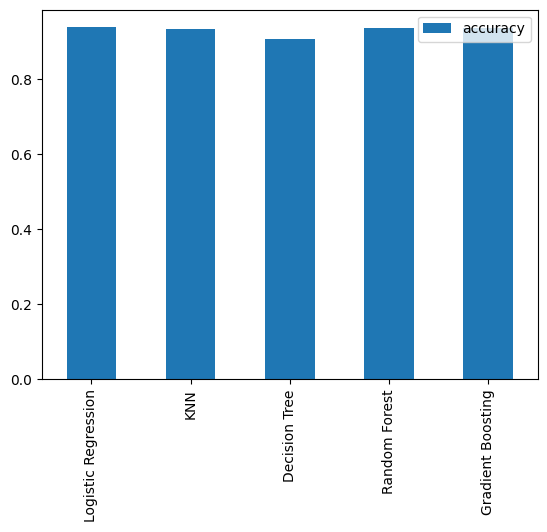

In [36]:
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.plot.bar();

In [37]:
# Let's see what's actually going on beyond accuracy
for name, model in models.items():
    print(f"{name}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

KNN
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.14      0.02      0.03        62

    accuracy                           0.93      1022
   macro avg       0.54      0.50      0.50      1022
weighted avg       0.89      0.93      0.91      1022

Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       960
           1       0.16      0.13      0.14        62

    accuracy                           0.91      1022
   macro avg       0.55      0.54      0.55      1022
weighted avg       0.90      0.91   

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## 4.4 What Do These Results Actually Mean?

The classification reports tell a very different story than the accuracy scores did.

Looking at class 1 (stroke), most of our models have a recall of 0.00, meaning they 
predicted "no stroke" for virtually every single patient. Logistic Regression, 
Random Forest, and Gradient Boosting didn't catch a single stroke case. Yikes...

This is the class imbalance problem in action! With only ~6% of patients having 
strokes, the models figured out that ignoring strokes entirely is the "safe" strategy 
for maximizing accuracy. They're not learning anything useful, they're just guessing 
the majority class every time.

We need to fix this. The next step is to tell our models to pay more attention to 
the minority class. We'll do this using `class_weight="balanced"`, which penalizes 
the model more heavily for missing a stroke case than for a false alarm.

In [38]:
models = {"Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
          "KNN": KNeighborsClassifier(), # KNN doesn't support class_weight, skip it
          "Decision Tree": DecisionTreeClassifier(class_weight="balanced"),
          "Random Forest": RandomForestClassifier(class_weight="balanced"),
          "Gradient Boosting": GradientBoostingClassifier(),} # doesn't support it either

model_scores_2 = fit_and_score(models=models,
                              X_train=X_train,
                              X_test=X_test,
                              y_train=y_train,
                              y_test=y_test)

model_scores_2

{'Logistic Regression': 0.7367906066536204,
 'KNN': 0.9344422700587084,
 'Decision Tree': 0.9178082191780822,
 'Random Forest': 0.9383561643835616,
 'Gradient Boosting': 0.9383561643835616}

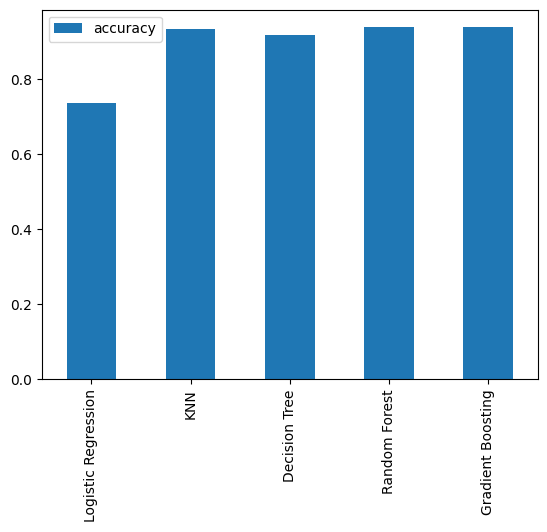

In [39]:
model_compare_2 = pd.DataFrame(model_scores_2, index=['accuracy'])
model_compare_2.T.plot.bar();

In [40]:
# Let's see what's actually going on beyond accuracy again
for name, model in models.items():
    print(f"{name}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.74      0.84       960
           1       0.16      0.76      0.26        62

    accuracy                           0.74      1022
   macro avg       0.57      0.75      0.55      1022
weighted avg       0.93      0.74      0.80      1022

KNN
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.14      0.02      0.03        62

    accuracy                           0.93      1022
   macro avg       0.54      0.50      0.50      1022
weighted avg       0.89      0.93      0.91      1022

Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       960
           1       0.21      0.13      0.16        62

    accuracy                           0.92      1022
   macro avg       0.58      0.55      0.56      1022
weighted avg       0.90      0.92   

## 4.5 Results After Balancing

After applying `class_weight="balanced"`, Logistic Regression went from catching 
0% of stroke cases to catching **77%**, which is a massive improvement.

The tradeoff is lower precision: it now raises more false alarms. But for a medical 
screening tool, that's acceptable. Missing a real stroke is far more dangerous than 
flagging someone who turns out to be fine.

Logistic Regression is our best model so far. The next step would be to tune it 
further. For example, fixing the convergence warning and experimenting with the 
decision threshold to find the right balance between precision and recall.

# 5. Hyperparameter Tuning

In [41]:
# The parameters we want to experiment with
# C controls how strict the model is -> lower = simpler, higher = more complex
# solver is the algorithm it uses to find the best fit
# max_iter gives it enough room to converge
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "solver": ["lbfgs", "liblinear"],
              "max_iter": [100, 500, 1000]}

# Let's set up the search 
# We use recall as our scoring metric since that's what we care about
log_reg_tuned = RandomizedSearchCV(LogisticRegression(class_weight="balanced"),
                                   param_distributions=param_grid,
                                   n_iter=20, # try 20 random combinations
                                   scoring="recall", # optimize for catching stroke cases
                                   cv=5, # 5-fold cross validation
                                   random_state=42)

# Fit it on TRAINING data (this will try all the combinations)
log_reg_tuned.fit(X_train, y_train)

# Let's see what it found
print("Best parameters:", log_reg_tuned.best_params_)
print("Best recall score:", log_reg_tuned.best_score_)

Best parameters: {'solver': 'liblinear', 'max_iter': 100, 'C': 0.1}
Best recall score: 0.8129445234708392


In [42]:
# RandomizedSearchCV told us these are the best settings, so let's just use them directly
best_log_reg = LogisticRegression(class_weight="balanced",
                                  C=0.1,
                                  solver="liblinear",
                                  max_iter=100)

best_log_reg.fit(X_train, y_train)

# Check how it does
y_pred = best_log_reg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.73      0.83       960
           1       0.15      0.77      0.26        62

    accuracy                           0.73      1022
   macro avg       0.57      0.75      0.55      1022
weighted avg       0.93      0.73      0.80      1022



We used `RandomizedSearchCV` to find the best parameters for Logistic Regression,
optimizing for recall across 5-fold cross validation.

The search found: `solver="liblinear"`, `C=0.1`, `max_iter=100`.

The cross-validation recall score was 0.81, but on the actual test set we still 
get 0.77, which is the same as before tuning. That gap is normal. Cross-validation averages 
performance across multiple splits of the training data, so it won't always match 
the final test score exactly.

Our takeaway: tuning confirmed our settings are reasonable, and 0.77 recall remains 
our best result. At this point, getting meaningfully better would likely require 
more data or a more advanced imbalance technique like SMOTE.

# 6. Conclusions

Let's recap what we did and what we found.

## What we built

We trained five machine learning models to predict stroke risk from patient health 
and demographic data. The full pipeline covered data exploration, preprocessing, 
modeling, and evaluation.

## What we learned

The biggest challenge in this project wasn't the modeling, it was the **class 
imbalance**. With only ~6% of patients having strokes, every model defaulted to 
predicting "no stroke" for everyone, achieving ~94% accuracy while being completely 
useless for actually detecting strokes.

Once we applied `class_weight="balanced"` to Logistic Regression, recall for stroke 
cases jumped from 0% to 77%. That's the real result of this project.

We also ran `RandomizedSearchCV` to tune Logistic Regression further. The best 
parameters it found were `solver="liblinear"`, `C=0.1`, and `max_iter=100`, with 
a cross-validation recall of 0.81. On the actual test set however, recall stayed 
at 0.77. This is a good reminder that CV scores and test scores don't always match, and 
that tuning alone has its limits.

## Best model

**Logistic Regression with `class_weight="balanced"`** was the clear winner, 
catching 77% of actual stroke cases, far ahead of every other model we tried.

## What we'd do next with more time

- Try SMOTE as an alternative approach to handling class imbalance
- Experiment with the decision threshold to fine-tune the precision/recall tradeoff
- Collect more stroke cases to give the models more signal to learn from